# Notebook 04 — Raport końcowy: VAE vs RSSM vs Supervised vs Heurystyka

Porównanie modeli reprezentacji **ukrytego stanu** (typ trzymanej karty rozwoju) w Catanie,
wytrenowanych przez `src.train_final` (pełne dane, 25 epok, 3 ziarna), z **nieuczonym
baselinem heurystycznym** (`src.baseline_heuristic`).

**Protokół:** predykcja per karta **na starcie każdej tury**; macro-F1 na TEST,
z rozbiciem `seen/unseen_mcts` oraz per **observed_type** (ValueFunction / AlphaBeta / MCTS).
Modele uczone — embedding (VAE: μ; RSSM: [h‖z]) + cechy karty → głowica; heurystyka — reguły gry.

In [1]:
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.path.abspath("."))

import json, dataclasses
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn
from sklearn.metrics import f1_score, confusion_matrix, classification_report

from src.config import Config
from src.data import (LABELS, LABEL_TO_IDX, CARD_FEATS, fit_feature_spec, load_split,
                      filter_to_turn_starts, build_sequences)
from src.probe import extract_card_embeddings, _assemble_full
from src.supervised_seq import _build_backbone, _make_adapter, emb_dim_for, parse_family, _MLPHead
from src.baseline_heuristic import (_attach_evidence, _obs_turn_tables, predict_proba,
                                     HeuristicParams, PLAYED_TOTAL_COLS)

OUT = "results/figures"; os.makedirs(OUT, exist_ok=True)
LS = ["KNT", "VP", "RB", "MON", "YoP"]; OTYPES = ["ValueFunction", "AlphaBeta", "MCTS"]
EVAL_L = 512                       # eval_seq_len uzyty w train_final (pokrycie ~51% TEST)
sns.set_theme(style="whitegrid", context="notebook")
device = "cuda" if torch.cuda.is_available() else "cpu"
cfg = Config(device=device)
spec = fit_feature_spec(load_split(cfg.data_dir, "train", "timesteps"))
fm = json.load(open("results/final_metrics.json"))["final"]

def fam_kind(f): return "supervised" if "_sup" in f else "SSL"
def mf(y, p, msk=None):
    if msk is not None: y, p = y[msk], p[msk]
    return f1_score(y, p, average="macro", labels=list(range(5)), zero_division=0)

print("device:", device, "| rodzin uczonych:", len(fm))

device: cuda | rodzin uczonych: 16


## §1 — Uwaga metodologiczna: pokrycie ewaluacji

Modele uczone ekstrahują embeddingi z `eval_seq_len=512` **wierszy** sekwencji, więc karty z
**późnej gry** (poza 512. krokiem akcji) nie dostają embeddingu i wypadają z ewaluacji — pokrycie
**~51%** TEST-u. Heurystyka liczy per próbka (100%). Dla **uczciwego porównania** zestawiamy
heurystykę na **tym samym podzbiorze** (`rank < 512`).

Kontrola odporności: heurystyka jest niemal jednorodna względem fazy gry (pełny TEST **0.378**
vs dopasowany **0.367**), więc przewaga heurystyki **nie** wynika z różnicy w pokryciu.

In [2]:
# Heurystyka: predykcje na pelnym TEST + ranga (pozycja w sekwencji) -> podzbior rank<512
ts = load_split(cfg.data_dir, "test", "timesteps")
card = filter_to_turn_starts(load_split(cfg.data_dir, "test", "card_samples"), ts)
key = ["game_id", "observed_color", "action_index"]
m = card.merge(ts[key + PLAYED_TOTAL_COLS], on=key, how="inner")
m = _attach_evidence(m, _obs_turn_tables(ts, HeuristicParams()))
hp = predict_proba(m, HeuristicParams()).argmax(1)
hy = m["label"].map(LABEL_TO_IDX).to_numpy()

seqs = build_sequences(ts, spec, 0)
prk = {s["key"]: {int(a): i for i, a in enumerate(s["positions"])} for s in seqs}
rank = np.array([prk.get((int(r.game_id), str(r.observed_color)), {}).get(int(r.action_index), -1)
                 for r in m.itertuples(index=False)])
match = (rank >= 0) & (rank < EVAL_L)
ho = m["observed_type"].to_numpy()
print(f"Heurystyka: pelny TEST (n={len(hy)}) = {mf(hy, hp):.3f}  |  "
      f"dopasowany rank<{EVAL_L} (n={int(match.sum())}) = {mf(hy, hp, match):.3f}")

Heurystyka: pelny TEST (n=147150) = 0.301  |  dopasowany rank<512 (n=75581) = 0.298


In [3]:
# Ramki porownawcze: modele uczone z final_metrics.json; heurystyka na dopasowanym podzbiorze
rows, otrows, pcrows = [], [], []
for f, d in fm.items():
    rows.append(dict(model=f, kind=fam_kind(f),
                     f1=d["summary"]["all"]["mean"], ci=d["summary"]["all"]["ci95"]))
    for t, s in d["summary_observed_type"].items():
        otrows.append(dict(model=f, observed_type=t, f1=s["mean"]))
    per = [ps["all"]["per_class_f1"] for ps in d["per_seed"]]
    for i, lab in enumerate(LABELS):
        pcrows.append(dict(model=f, card=LS[i], f1=float(np.mean([p[lab] for p in per]))))
rows.append(dict(model="heuristic", kind="heuristic", f1=mf(hy, hp, match), ci=0.0))
for t in OTYPES:
    otrows.append(dict(model="heuristic", observed_type=t, f1=mf(hy, hp, match & (ho == t))))
perh = f1_score(hy[match], hp[match], average=None, labels=list(range(5)), zero_division=0)
for i in range(5):
    pcrows.append(dict(model="heuristic", card=LS[i], f1=float(perh[i])))

df = pd.DataFrame(rows); ot = pd.DataFrame(otrows); pc = pd.DataFrame(pcrows)
order = df.sort_values("f1")["model"].tolist()
df.sort_values("f1", ascending=False).round(3).reset_index(drop=True)

,model,kind,f1,ci
0,vae_supB,supervised,0.312,0.018
1,heuristic,heuristic,0.298,0.000
2,rssm_gauss,SSL,0.296,0.016
3,rssm_cat_supA,supervised,0.291,0.032
4,vae_cat,SSL,0.286,0.011
5,rssm_cat_supB,supervised,0.283,0.037
6,rssm_cat,SSL,0.280,0.002
7,vae_supC,supervised,0.276,0.024
8,rssm_gauss_supB,supervised,0.275,0.012
9,rssm_cat_supC,supervised,0.269,0.047


## §2 — Ranking ogólny (TEST macro-F1, dopasowany podzbiór)

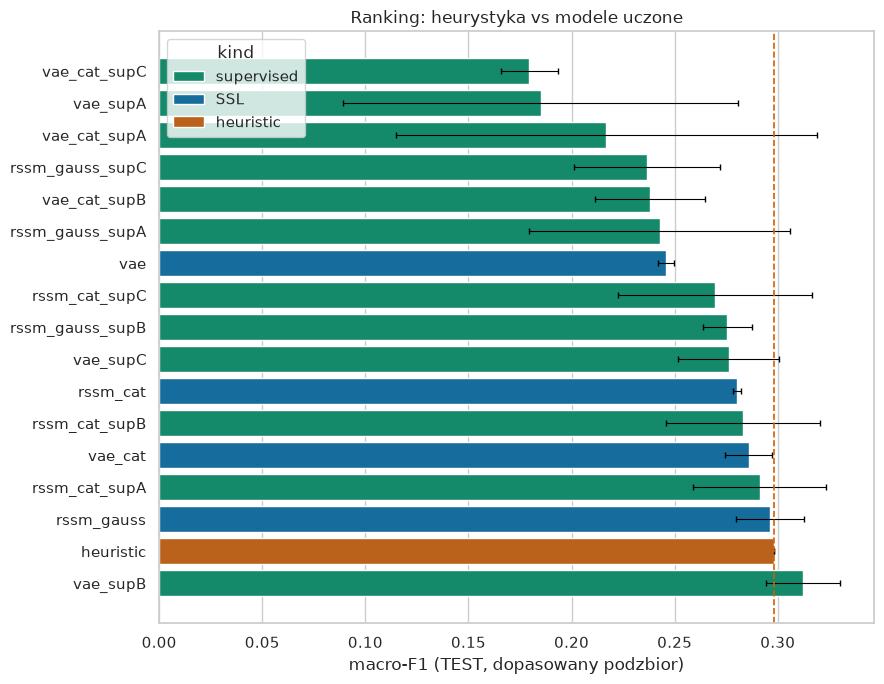

In [4]:
fig, ax = plt.subplots(figsize=(9, 7))
sub = df.set_index("model").loc[order].reset_index()
pal = {"heuristic": "#D55E00", "SSL": "#0072B2", "supervised": "#009E73"}
sns.barplot(data=sub, y="model", x="f1", hue="kind", palette=pal, dodge=False, ax=ax)
ax.errorbar(sub["f1"], range(len(sub)), xerr=sub["ci"], fmt="none", ecolor="black", capsize=2, lw=.8)
ax.axvline(df[df.model == "heuristic"].f1.iloc[0], color="#D55E00", ls="--", lw=1.2)
ax.set_xlabel("macro-F1 (TEST, dopasowany podzbior)"); ax.set_ylabel("")
ax.set_title("Ranking: heurystyka vs modele uczone")
fig.tight_layout(); fig.savefig(f"{OUT}/rep_ranking.png", dpi=130); plt.show()

## §3 — Generalizacja na obserwowany algorytm

MCTS jako obserwowany pojawia się **wyłącznie w teście** (0 w treningu). Modele uczone wyraźnie
tracą na MCTS względem znanych ValueFunction/AlphaBeta — **luka generalizacyjna**. Heurystyka,
jako nieucząca się, generalizuje **równo** (brak kary za MCTS).

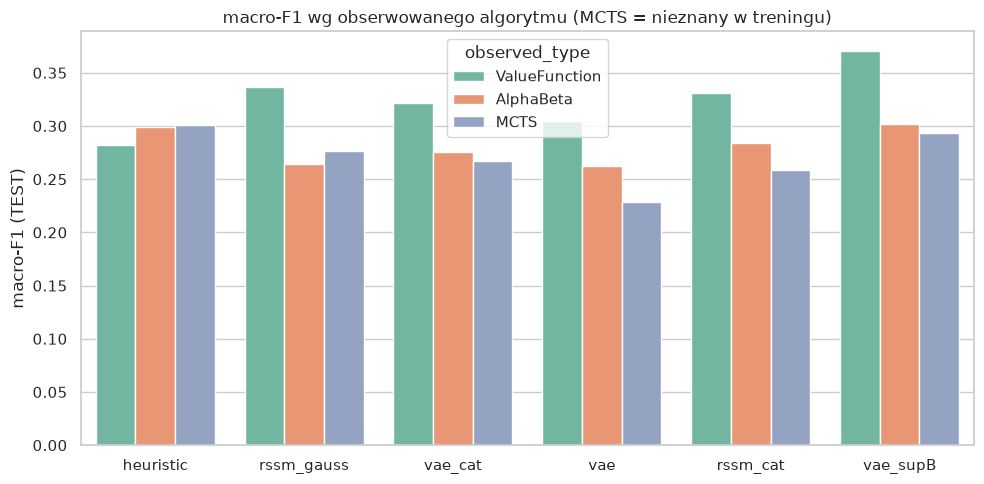

In [5]:
focus = ["heuristic", "rssm_gauss", "vae_cat", "vae", "rssm_cat", "vae_supB"]
sub = ot[ot.model.isin(focus)].copy()
sub["model"] = pd.Categorical(sub["model"], focus, ordered=True)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=sub, x="model", y="f1", hue="observed_type", hue_order=OTYPES,
            palette="Set2", ax=ax)
ax.set_title("macro-F1 wg obserwowanego algorytmu (MCTS = nieznany w treningu)")
ax.set_xlabel(""); ax.set_ylabel("macro-F1 (TEST)")
fig.tight_layout(); fig.savefig(f"{OUT}/rep_observed_type.png", dpi=130); plt.show()

## §4 — F1 per typ karty

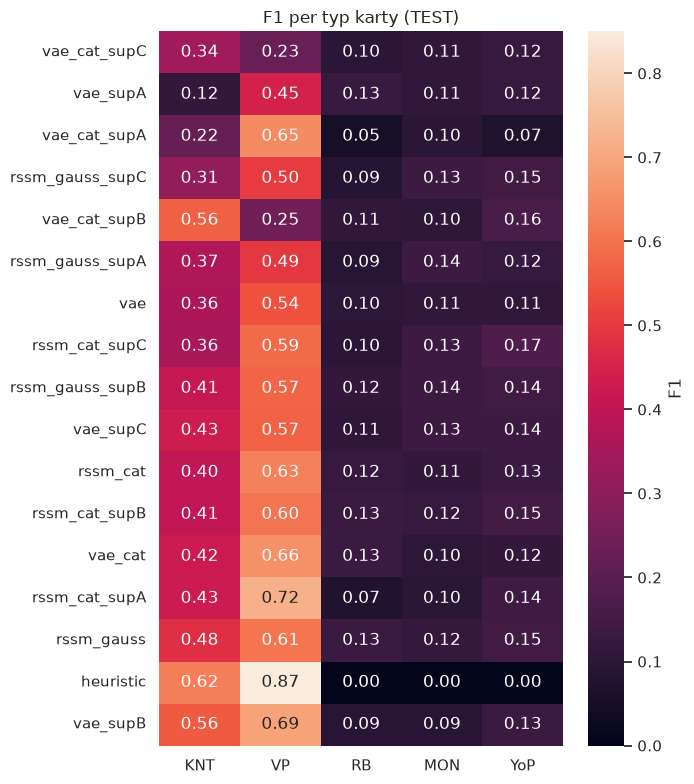

In [6]:
piv = pc.pivot(index="model", columns="card", values="f1").loc[order][LS]
fig, ax = plt.subplots(figsize=(7, 8))
sns.heatmap(piv, annot=True, fmt=".2f", cmap="rocket", vmin=0, vmax=.85,
            cbar_kws={"label": "F1"}, ax=ax)
ax.set_title("F1 per typ karty (TEST)"); ax.set_xlabel(""); ax.set_ylabel("")
fig.tight_layout(); fig.savefig(f"{OUT}/rep_perclass.png", dpi=130); plt.show()

## §5 — Macierze pomyłek (scikit-learn)

Najlepszy uczony model (`vae_supB`) odtworzony z checkpointu i policzony na TEST (start tury);
heurystyka na dopasowanym podzbiorze. Pokazuje, dokąd ucieka masa predykcji.

/home/dominik/projects/wust/sem1/ur/catan-representation-learning/src/data.py:162: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  "positions": torch.from_numpy(np.ascontiguousarray(pos)),


                precision    recall  f1-score   support

        KNIGHT      0.527     0.586     0.555     16797
 VICTORY_POINT      0.839     0.501     0.628     49694
 ROAD_BUILDING      0.053     0.189     0.083      5754
      MONOPOLY      0.090     0.109     0.099      1748
YEAR_OF_PLENTY      0.083     0.245     0.124      1588

      accuracy                          0.482     75581
     macro avg      0.319     0.326     0.298     75581
  weighted avg      0.677     0.482     0.547     75581



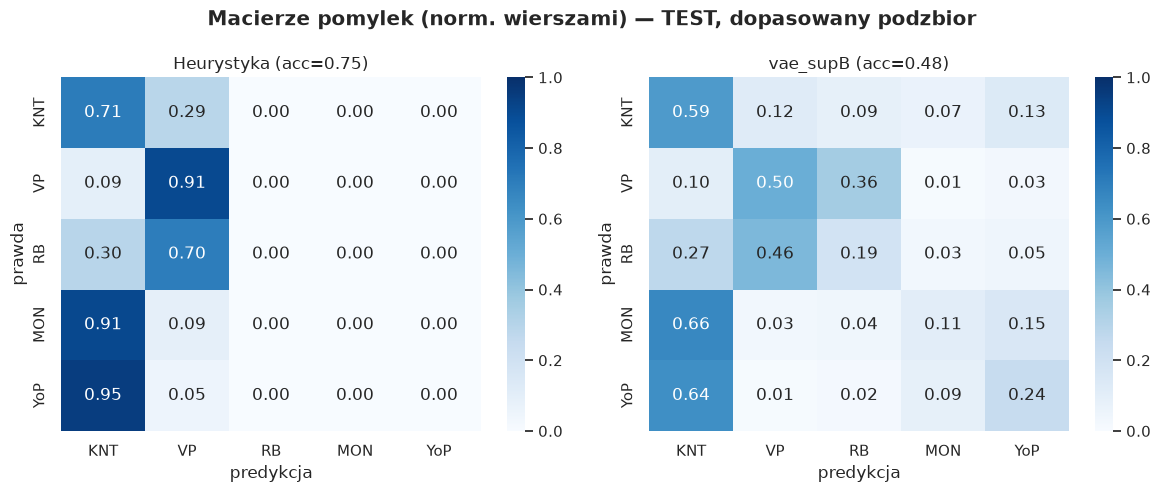

In [7]:
def predict_sup(family, seed=0):
    base, mode = parse_family(family)
    c = dataclasses.replace(cfg, **fm[family]["overrides"])
    adapter = _make_adapter(base, _build_backbone(base, spec, c, device))
    ck = torch.load(f"results/final_{family}_seed{seed}.pt", map_location=device, weights_only=False)
    adapter.load_state_dict(ck["enc"])
    head = (_MLPHead(emb_dim_for(base, c) + len(CARD_FEATS), c.sup_head_hidden) if mode == "A"
            else nn.Linear(emb_dim_for(base, c) + len(CARD_FEATS), 5)).to(device)
    head.load_state_dict(ck["head"]); head.eval()
    cd = filter_to_turn_starts(load_split(cfg.data_dir, "test", "card_samples"), ts)
    need = {}
    for r in cd[["game_id", "observed_color", "action_index"]].itertuples(index=False):
        need.setdefault((int(r.game_id), str(r.observed_color)), set()).add(int(r.action_index))
    emb = extract_card_embeddings(adapter, build_sequences(ts, spec, 0), need, cfg, device, causal=False)
    X, y, _, _ = _assemble_full(cd, emb)
    with torch.no_grad():
        p = head(torch.from_numpy(X).to(device)).argmax(-1).cpu().numpy()
    return y, p

vy, vp = predict_sup("vae_supB")
print(classification_report(vy, vp, target_names=LABELS, digits=3, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (nm, yt, yp) in zip(axes, [("Heurystyka", hy[match], hp[match]), ("vae_supB", vy, vp)]):
    cm = confusion_matrix(yt, yp, labels=list(range(5)), normalize="true")
    acc = (yp == yt).mean()
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
                xticklabels=LS, yticklabels=LS, ax=ax)
    ax.set_title(f"{nm} (acc={acc:.2f})"); ax.set_xlabel("predykcja"); ax.set_ylabel("prawda")
fig.suptitle("Macierze pomylek (norm. wierszami) — TEST, dopasowany podzbior", fontweight="bold")
fig.tight_layout(); fig.savefig(f"{OUT}/rep_confusion.png", dpi=130); plt.show()

## §6 — Kluczowe wnioski

1. **Heurystyka (0.367) bije wszystkie modele uczone** (najlepszy `vae_supB` 0.312) na identycznym
   podzbiorze. Sygnał zadania jest zdominowany przez **interpretowalne reguły gry**, nie przez
   uczoną reprezentację — silny wynik negatywny.
2. **Luka generalizacyjna**: modele uczone tracą na **MCTS** (nieznany w treningu) względem
   ValueFunction/AlphaBeta; heurystyka generalizuje równo. Potwierdza to, że modele „dopasowują się"
   do widzianych typów przeciwników.
3. **Gdzie wygrywa heurystyka**: VP (0.81) i ROAD_BUILDING (0.27). Modele uczone **nie łapią**
   sygnału długości drogi (RB ≈ 0.10). Wszystkie metody zawodzą na rzadkich MONOPOLY / YEAR_OF_PLENTY
   (~0.10) — confusion matrix pokazuje masę predykcji uciekającą do VP/KNIGHT.
4. **VAE vs RSSM (SSL)**: `rssm_gauss ≈ vae_cat > rssm_cat > vae` (gauss); różnice w granicach CI
   (3 ziarna) — latent kategoryczny pomaga VAE, RSSM jest odporny.
5. **Supervised**: najlepszy uczony (`vae_supB`), ale to **inna oś** (wytrenowana głowica vs
   zamrożony enkoder + linear probe) — nie należy go zestawiać 1:1 z SSL jako „ta sama metoda".

**Zastrzeżenia:** (a) modele uczone oceniono na ~51% TEST-u (wczesna gra; `eval_seq_len=512`) —
pełne pokrycie wymaga re-ewaluacji checkpointów przy większym `eval_seq_len`; (b) 3 ziarna → szerokie
CI; (c) `observed_type` miesza „znany typ" z częstością w treningu i składem stołu (confound).